In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/sylviacoder/Investor-Profiling-Risk-Prediction-System/refs/heads/main/data/raw/Finance_data.csv')
df.columns = df.columns.str.strip()

###Basic string cleaning

In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,40,2,Male,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,40.0,NaN,NaN,NaN,27.8,3.560467,21.0,25.75,27.0,30.0,35.0
Investment_Avenues,40,2,Yes,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mutual_Funds,40.0,NaN,NaN,NaN,2.55,1.197219,1.0,2.0,2.0,3.0,7.0
Equity_Market,40.0,NaN,NaN,NaN,3.475,1.131994,1.0,3.0,4.0,4.0,6.0
Debentures,40.0,NaN,NaN,NaN,5.75,1.675617,1.0,5.0,6.5,7.0,7.0
Government_Bonds,40.0,NaN,NaN,NaN,4.65,1.369072,1.0,4.0,5.0,5.0,7.0
Fixed_Deposits,40.0,NaN,NaN,NaN,3.575,1.795828,1.0,2.75,3.5,5.0,7.0
PPF,40.0,NaN,NaN,NaN,2.025,1.609069,1.0,1.0,1.0,2.25,6.0
Gold,40.0,NaN,NaN,NaN,5.975,1.143263,2.0,6.0,6.0,7.0,7.0


###No inconsistencies seen in the dataset statistial summary. Count appears to be consistent throughout project features

In [18]:
df.columns

Index(['gender', 'age', 'Investment_Avenues', 'Mutual_Funds', 'Equity_Market',
       'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold',
       'Stock_Marktet', 'Factor', 'Objective', 'Purpose', 'Duration',
       'Invest_Monitor', 'Expect', 'Avenue',
       'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual',
       'Reason_Bonds', 'Reason_FD', 'Source'],
      dtype='object')

#### Feature Engineering factors to aid newly created target variable

In [20]:
df['Risky_Score'] = df['Equity_Market'] + df['Mutual_Funds']
df['Safe_Score'] = df['Fixed_Deposits'] + df['Government_Bonds']

Risky_Score and Safe_Score were created to measure an investor’s risk tolerance by grouping similar investment preferences. Equity_Market and Mutual_Funds were combined as high-risk investment options, while Fixed_Deposits and Government_Bonds were combined as low-risk options. This feature engineering helps the model better identify conservative and aggressive investor behavior patterns.

In [39]:
def classify_investor(row):

    agg_score = 0
    con_score = 0
    if row['Risky_Score'] <= 5:
        agg_score += 2
    if row['Safe_Score'] <= 5:
        con_score += 2
    if row['Expect'] == '30%-40%':
        agg_score += 1
    elif row['Expect'] == '10%-20%':
        con_score += 1

    if row['Duration'] == 'More than 5 years':
        agg_score += 1
    elif row['Duration'] == 'Less than 1 year':
        con_score += 1

    if agg_score > con_score:
        return 'Aggressive'
    elif con_score > agg_score:
        return 'Conservative'
    else:
        return 'Moderate'

df['Investor_Profile'] = df.apply(classify_investor, axis=1)

The Investor_Profile target variable was created using a rule-based scoring system that classifies investors as Aggressive, Conservative, or Moderate based on their investment preferences, expected returns, and investment duration. Higher preference for risky assets, higher return expectations, and longer investment periods indicate aggressive behavior, while preference for safer assets, lower return expectations, and shorter durations indicate conservative behavior. This helps convert survey responses into meaningful investor risk profiles for machine learning analysis.

In [41]:
df['Investor_Profile'].value_counts()

Investor_Profile
Aggressive      20
Moderate        18
Conservative     2
Name: count, dtype: int64

Low class representation

In [43]:
df.dtypes

gender                               object
age                                   int64
Investment_Avenues                   object
Mutual_Funds                          int64
Equity_Market                         int64
Debentures                            int64
Government_Bonds                      int64
Fixed_Deposits                        int64
PPF                                   int64
Gold                                  int64
Stock_Marktet                        object
Factor                               object
Objective                            object
Purpose                              object
Duration                             object
Invest_Monitor                       object
Expect                               object
Avenue                               object
What are your savings objectives?    object
Reason_Equity                        object
Reason_Mutual                        object
Reason_Bonds                         object
Reason_FD                       

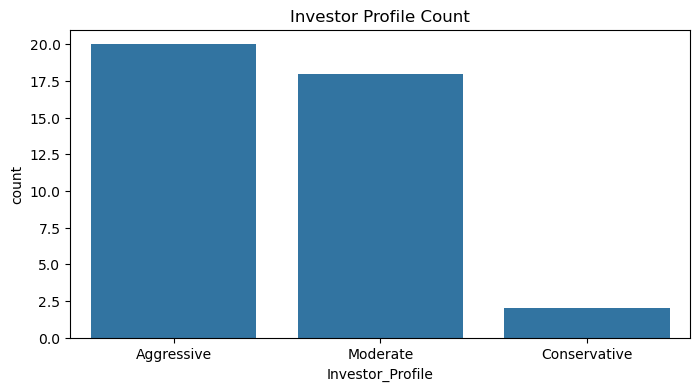

In [45]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Investor_Profile', order=['Aggressive', 'Moderate', 'Conservative'])
plt.title('Investor Profile Count')
plt.show()

The countplot visualization above shows a potential problem of low class representation in the Conservative Class. This would pose an issue if left unchecked. The model will have little or no prediction for conservative class i.e it would generally be overlooked.

Likely solutions would be to either use 'synthetic representation using SMOTE' or to 'actually alter the class from a multi-class to a binary class'.

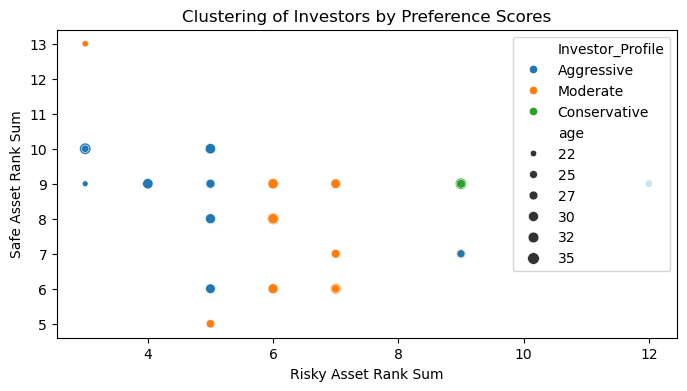

In [47]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Risky_Score', y='Safe_Score', hue='Investor_Profile', size='age')
plt.title('Clustering of Investors by Preference Scores')
plt.xlabel('Risky Asset Rank Sum')
plt.ylabel('Safe Asset Rank Sum')
plt.show()

This visualization was created to explore how investors are distributed based on their preference for risky and safe investment options. The scatter plot compares Risky_Score and Safe_Score while using color (hue) to distinguish different investor profiles and point size to represent age.

The plot helps identify behavioral patterns and potential clustering among aggressive, conservative, and moderate investors. It also provides insight into how age and investment preferences relate to overall investor risk tolerance.

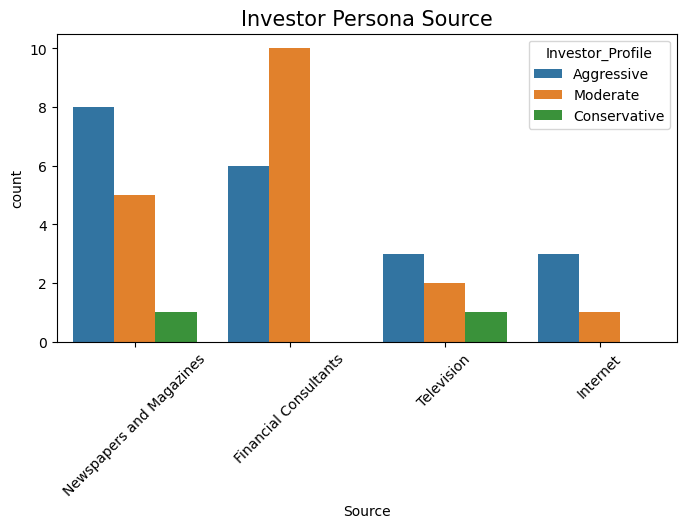

In [49]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Source', hue='Investor_Profile')
plt.title('Investor Persona Source', fontsize=15)
plt.xticks(rotation=45)
plt.show()

This visualization was created to analyze the relationship between investors’ information sources and their investor profiles. The count plot shows how different investor types (Aggressive, Moderate, and Conservative) are distributed across various investment information sources.
It helps identify patterns in where investors obtain financial knowledge and whether certain sources are more associated with specific investment behaviors or risk preferences.

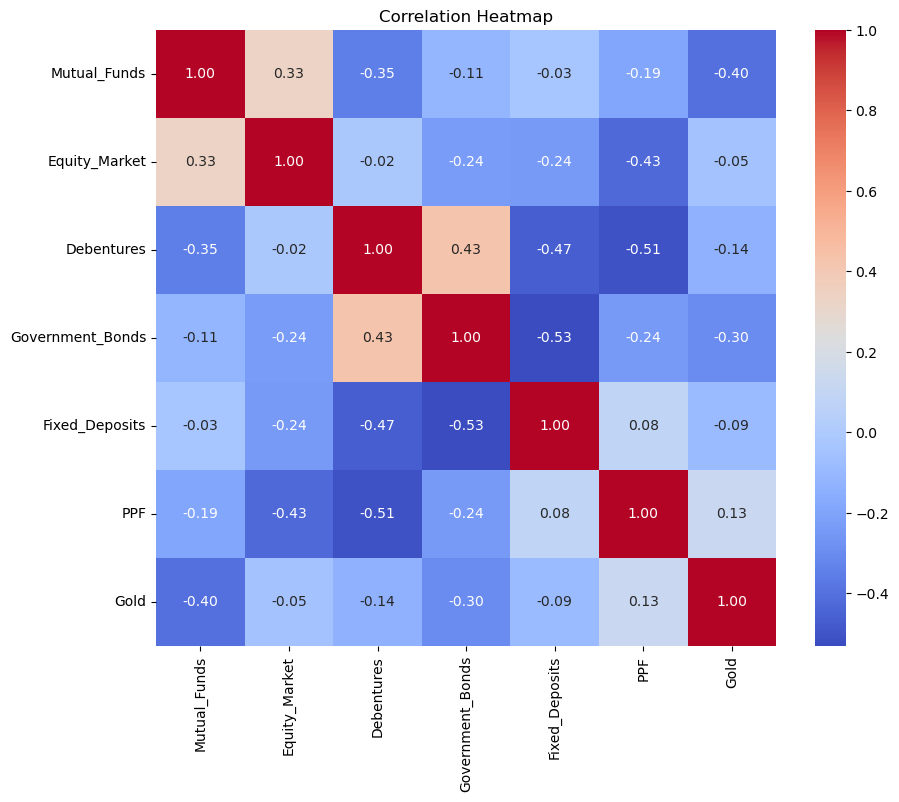

In [51]:
cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [53]:
df.to_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Investor Persona\cleaned_data.csv',index=False)

Processed File Saved